# **Project Title**: Identifying Early Signs of U.S. Economic Recessions Using Historical Data
**Group ID**: 5

**Members**: May Sabai, Emily Lu

## Processing Data
As current data doesn't have updated Inflation information, we will exclude it from data compairson.

In [1]:
# install libraries from Yahoo Finance Data
!pip install yfinance fredapi

In [2]:
# import necessary libraries
import yfinance as yf
import pandas as pd
from fredapi import Fred
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
import math

In [3]:
# API key from FRED to extract data
fred = Fred(api_key="65796ccf4eea28ff944ebb1cf7ea91de")

We have mentioned that we will use data from 1960, however, the first recession started in 1961. Based on our current exploration, we need more than 1 year of information to detect patterns. Therefore, we have decided to drop the 1961 economic recession from our analysis.

### Importing data

In [16]:
# Load data from FRED
# Unemployment Rate
unemployment = fred.get_series("UNRATE")

# Interest Rate
interest = fred.get_series("DFF")

# Oil Reserve Data
oil = fred.get_series("DCOILWTICO")

In [17]:
# Convert imported data to dataframe
unemployment = unemployment.to_frame(name="Unemployment")
interest = interest.to_frame(name="Interest")
oil = oil.to_frame(name="Oil")

# Load data starting from 1968
unemployment = unemployment[unemployment.index >= "1968-01-01"]
interest = interest[interest.index >= "1968-01-01"]

# Load data from Yahoo Finance
# S&P 500 data
sp500 = yf.download("^GSPC", start="1968-01-01")['Close']

# Data start from 1990
# VIX
vix = yf.download("^VIX", start="1990-01-01")['Close']

# Gold data
gold = yf.download("^XAU", start="1990-01-01")['Close']

/tmp/ipykernel_14295/1538937248.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download("^GSPC", start="1968-01-01")['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_14295/1538937248.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix = yf.download("^VIX", start="1990-01-01")['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_14295/1538937248.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold = yf.download("^XAU", start="1990-01-01")['Close']
[*********************100%***********************]  1 of 1 completed


In [18]:
# Recession data is stored in monthly format
# Convert all data into monthly for consistency

# unemployment (monthly)
unemployment_monthly = unemployment.resample("ME").last()

# Interest rate (monthly)
interest_monthly = interest.resample("ME").last()

# oil (monthly)
oil_monthly = oil.resample("ME").last()

# S&P 500 (daily -> monthly)
sp500_monthly = sp500.resample("ME").last()

# VIX (daily -> monthly)
vix_monthly = vix.resample("ME").last()

# Gold (daily -> monthly)
gold_monthly = gold.resample("ME").last()

**Economic recessions**

1. Dec 1969 – Nov 1970 (Vietnam War spending + Fed tightening to fight inflation)
2. Nov 1973 – Mar 1975 (Oil embargo (OPEC) → energy crisis and stagflation)
3. Jan 1980 – Jul 1980 (Fed sharply raised interest rates to control high inflation)
4. Jul 1981 – Nov 1982 (Continued high interest rates under Volcker crushed inflation but caused deep unemployment)
5. Jul 1990 – Mar 1991 (Gulf War oil shock + savings and loan crisis)
6. Mar 2001 – Nov 2001 (Dot-com bubble burst, tech layoffs, stock market crash)
7. Dec 2007 – Jun 2009 (Housing bubble collapse, banking crisis, Great Recession)
8. *Feb* 2020 – Apr 2020 (COVID-19 pandemic shutdowns, sudden job losses)

In [7]:
# Load recession indicator
recession = fred.get_series("USREC")
recession = recession.to_frame(name="Recession")
recession = recession[recession.index >= "1968-01-01"]
recession = recession.resample("ME").last()

recession.head()

,Recession
1968-01-31,0.0
1968-02-29,0.0
1968-03-31,0.0
1968-04-30,0.0
1968-05-31,0.0


In [19]:
econ_cols = {"Unemployment", "Interest", "Oil"}
fin_cols = {"SP500", "VIX", "Gold"}

# Define the color map
color_map = {
    "Unemployment": "blue",
    "Interest":     "red",
    "Oil":          "black",
    "SP500":        "green",
    "VIX":          "purple",
    "Gold":         "orange"
}

# Get Current Economic Data

In [20]:
# Combine all monthly datasets
current_df = pd.concat([
    unemployment_monthly,
    interest_monthly,
    oil_monthly,
    sp500_monthly,
    vix_monthly,
    gold_monthly
], axis=1)

# Rename column names
current_df = current_df.rename(columns={
    '^GSPC': 'SP500',
    '^VIX': 'VIX',
    '^XAU': 'Gold',
})

# Filter date range
current_df = current_df.loc["2024-04-01":"2026-03-31"]

# Handle missing values (important)
current_df = current_df.ffill().bfill()

current_df

,Unemployment,Interest,Oil,SP500,VIX,Gold
2024-04-30,3.9,5.33,83.49,5035.689941,15.650000,133.449997
2024-05-31,3.9,5.33,77.97,5277.509766,12.920000,145.160004
2024-06-30,4.1,5.33,82.83,5460.479980,12.440000,137.369995
2024-07-31,4.2,5.33,79.36,5522.299805,16.360001,152.330002
2024-08-31,4.2,5.33,74.52,5648.399902,15.000000,153.910004
2024-09-30,4.1,4.83,68.75,5762.479980,16.730000,158.720001
2024-10-31,4.1,4.83,69.58,5705.450195,23.160000,161.199997
2024-11-30,4.2,4.58,68.26,6032.379883,13.510000,150.470001
2024-12-31,4.1,4.33,72.44,5881.629883,17.350000,137.179993
2025-01-31,4.0,4.33,72.84,6040.529785,16.430000,153.990005


## Heatmap for % changes in financial indicators

### Monthly Data

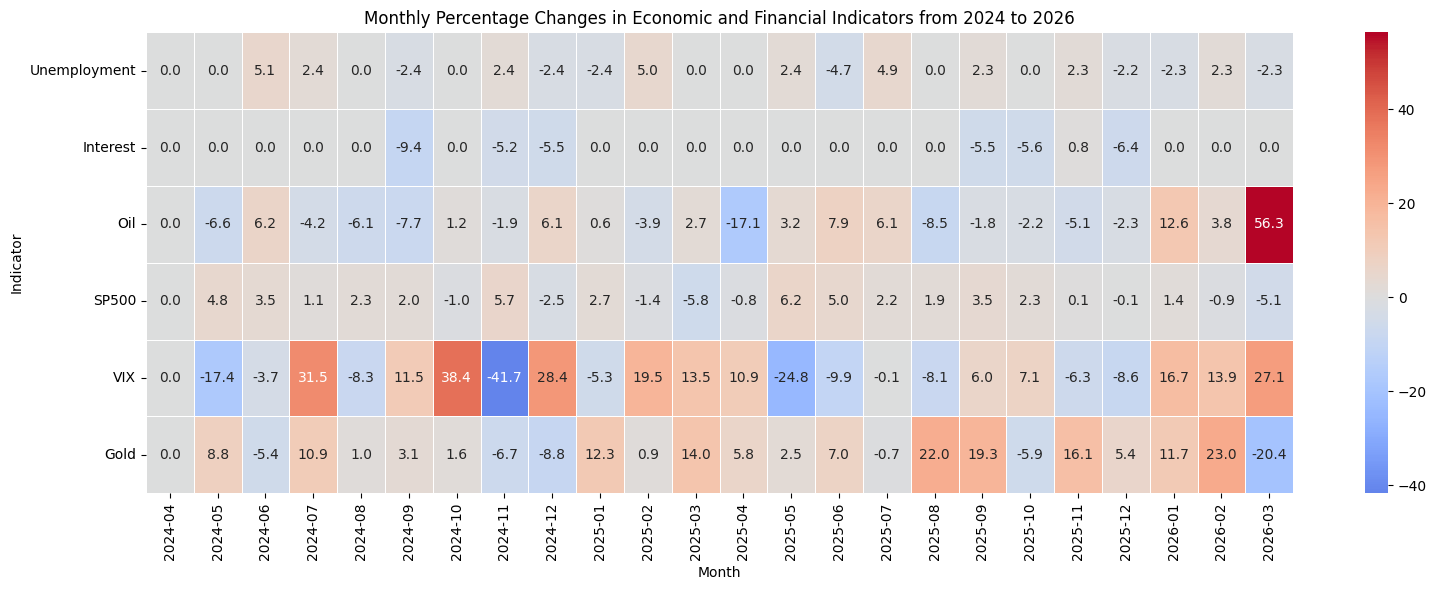

In [41]:
pct_change_df = current_df.pct_change() * 100
pct_change_df = pct_change_df.fillna(0)

# transpose so indicators are rows
heatmap_data = pct_change_df.T

# cleaner month labels
heatmap_data.columns = [d.strftime("%Y-%m") for d in heatmap_data.columns]

plt.figure(figsize=(16, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Monthly Percentage Changes in Economic and Financial Indicators from 2024 to 2026")
plt.xlabel("Month")
plt.ylabel("Indicator")
plt.tight_layout()
plt.show()


### Different time periods

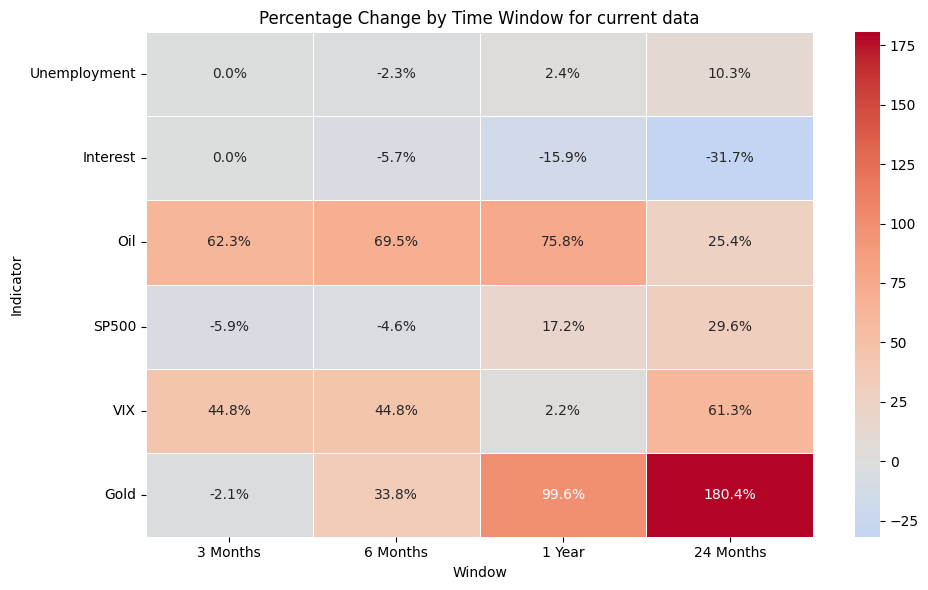

In [40]:
windows = {
    "3 Months": ("2026-01-01", "2026-03-31"),
    "6 Months": ("2025-10-01", "2026-03-31"),
    "1 Year":   ("2025-04-01", "2026-03-31"),
    "24 Months":("2024-04-01", "2026-03-31")
}

all_cols = current_df.columns.tolist()

heatmap_values = {}

for label, (start_date, end_date) in windows.items():
    window_df = current_df.loc[start_date:end_date, all_cols].copy()

    # If a column is all NaN in a window, return 0
    start_vals = window_df.iloc[0]
    end_vals = window_df.iloc[-1]

    pct_change = ((end_vals / start_vals) - 1) * 100

    # clean up inf/nan
    pct_change = pct_change.replace([np.inf, -np.inf], np.nan).fillna(0)

    heatmap_values[label] = pct_change

heatmap_df = pd.DataFrame(heatmap_values)

annot_data = heatmap_df.round(1).astype(str) + "%"

plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_df,
    annot=annot_data,
    fmt="",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Percentage Change by Time Window for current data")
plt.xlabel("Window")
plt.ylabel("Indicator")
plt.tight_layout()
plt.show()

## Side by Side line graphs
These line graphs will show the trend of each economic data between Apr 2024 to Mar 2026.

In [25]:
normalized_df = current_df[all_cols].copy()

for col in all_cols:
    first_valid = normalized_df[col].dropna()
    if not first_valid.empty:
        base_value = first_valid.iloc[0]
        normalized_df[col] = (normalized_df[col] / base_value) * 100
    else:
        normalized_df[col] = 100  # fallback if entire column missing

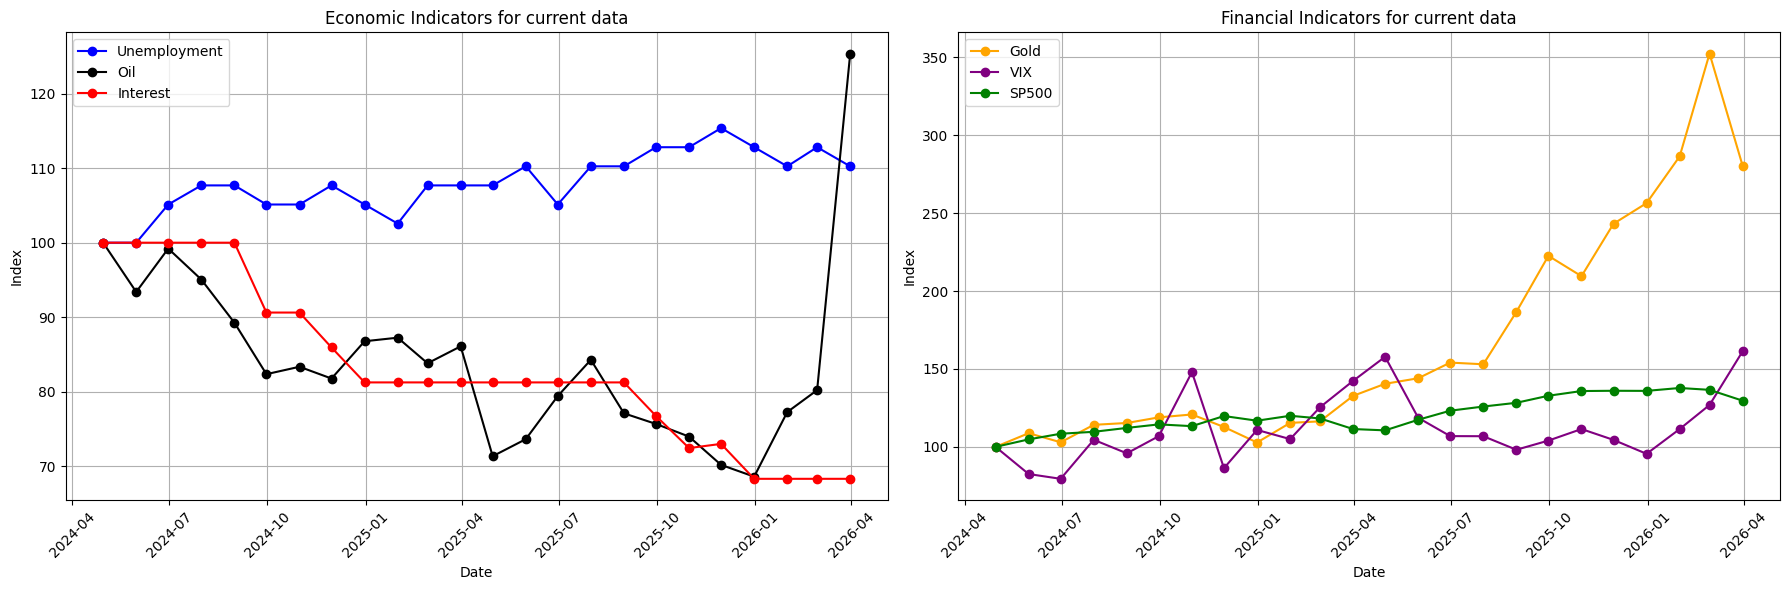

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Economic
for col in econ_cols:
    axes[0].plot(normalized_df.index, normalized_df[col],
                 marker="o", label=col, color=color_map[col])

axes[0].set_title("Economic Indicators for current data")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Index")
axes[0].legend()
axes[0].grid(True)
axes[0].tick_params(axis="x", rotation=45)

# Financial
for col in fin_cols:
    axes[1].plot(normalized_df.index, normalized_df[col],
                 marker="o", label=col, color=color_map[col])

axes[1].set_title("Financial Indicators for current data")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Index")
axes[1].legend()
axes[1].grid(True)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Compare with 1990 Gult War Recession


In [27]:
# Combine all monthly datasets
df_1990 = pd.concat([
    unemployment_monthly,
    interest_monthly,
    oil_monthly,
    sp500_monthly,
    vix_monthly,
    gold_monthly
], axis=1)

# Rename column names
df_1990 = df_1990.rename(columns={
    '^GSPC': 'SP500',
    '^VIX': 'VIX',
    '^XAU': 'Gold',
})

# Filter date range
df_1990 = df_1990.loc["1988-07-01":"1990-06-30"]

# Handle missing values (important)
df_1990 = df_1990.ffill().bfill()

df_1990

,Unemployment,Interest,Oil,SP500,VIX,Gold
1988-07-31,5.4,7.84,16.37,272.019989,25.360001,130.279999
1988-08-31,5.6,8.14,15.19,261.519989,25.360001,130.279999
1988-09-30,5.4,8.54,13.33,271.910004,25.360001,130.279999
1988-10-31,5.4,8.39,13.54,278.970001,25.360001,130.279999
1988-11-30,5.3,8.50,15.42,273.700012,25.360001,130.279999
1988-12-31,5.3,9.04,17.12,277.720001,25.360001,130.279999
1989-01-31,5.4,9.14,17.00,297.470001,25.360001,130.279999
1989-02-28,5.2,9.87,18.21,288.859985,25.360001,130.279999
1989-03-31,5.0,9.79,20.27,294.869995,25.360001,130.279999
1989-04-30,5.2,9.82,20.38,309.640015,25.360001,130.279999


## Heatmap for % changes in financial indicators

### Monthly Data

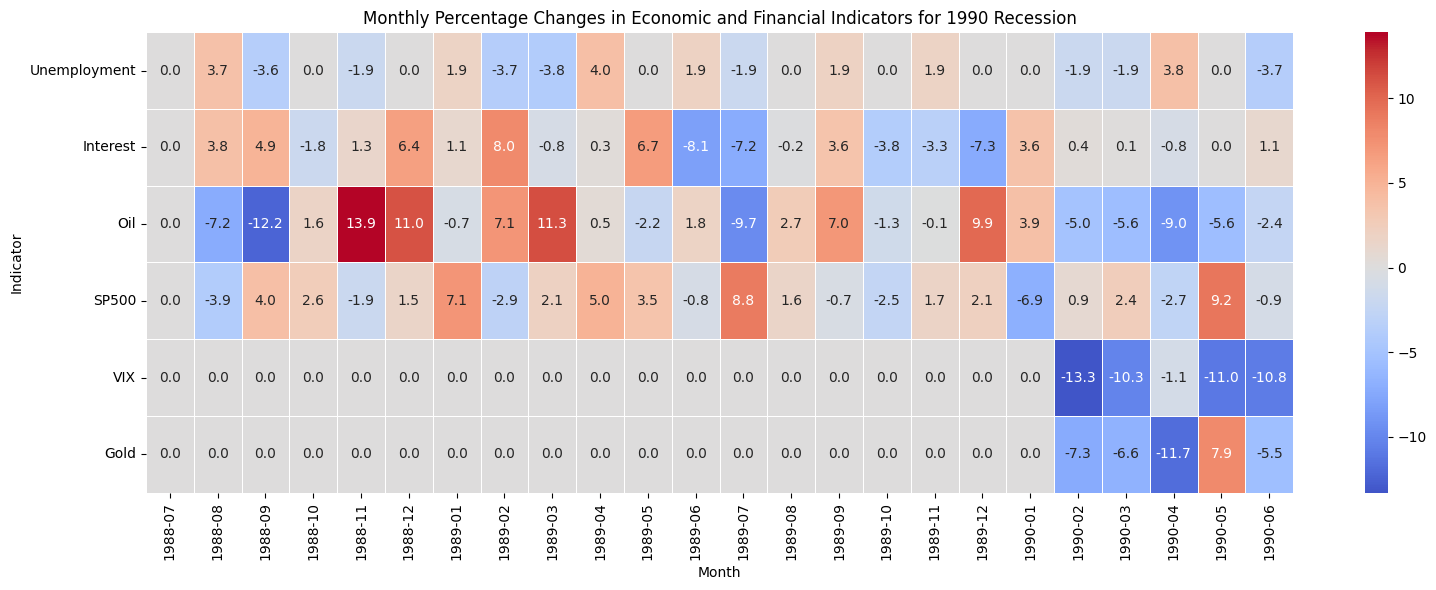

In [61]:
pct_change_df_1990 = df_1990.pct_change() * 100
pct_change_df_1990 = pct_change_df_1990.fillna(0)

# transpose so indicators are rows
heatmap_data_1990 = pct_change_df_1990.T

# cleaner month labels
heatmap_data_1990.columns = [d.strftime("%Y-%m") for d in heatmap_data_1990.columns]

plt.figure(figsize=(16, 6))
sns.heatmap(
    heatmap_data_1990,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Monthly Percentage Changes in Economic and Financial Indicators for 1990 Recession")
plt.xlabel("Month")
plt.ylabel("Indicator")
plt.tight_layout()
plt.show()


### Different time periods

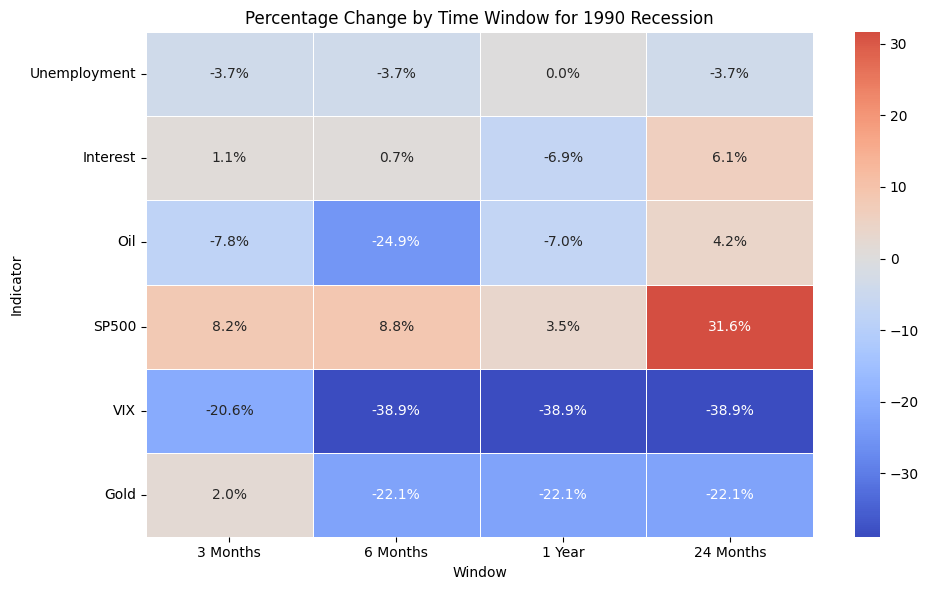

In [37]:
windows_1990 = {
    "3 Months": ("1990-04-01", "1990-06-30"),
    "6 Months": ("1990-01-01", "1990-06-30"),
    "1 Year":   ("1989-07-01", "1990-06-30"),
    "24 Months":("1988-07-01", "1990-06-30")
}

all_cols_1990 = df_1990.columns.tolist()

heatmap_values_1990 = {}

for label, (start_date, end_date) in windows_1990.items():
    window_df_1990 = df_1990.loc[start_date:end_date, all_cols_1990].copy()

    # If a column is all NaN in a window, return 0
    start_vals_1990 = window_df_1990.iloc[0]
    end_vals_1990 = window_df_1990.iloc[-1]

    pct_change_1990 = ((end_vals_1990 / start_vals_1990) - 1) * 100

    # clean up inf/nan
    pct_change_1990 = pct_change_1990.replace([np.inf, -np.inf], np.nan).fillna(0)

    heatmap_values_1990[label] = pct_change_1990

heatmap_df_1990 = pd.DataFrame(heatmap_values_1990)

annot_data_1990 = heatmap_df_1990.round(1).astype(str) + "%"

plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_df_1990,
    annot=annot_data_1990,
    fmt="",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Percentage Change by Time Window for 1990 Recession")
plt.xlabel("Window")
plt.ylabel("Indicator")
plt.tight_layout()
plt.show()

## Side by Side line graphs
These line graphs will show the trend of each economic data.

In [32]:
normalized_df_1990 = df_1990[all_cols_1990].copy()

for col in all_cols_1990:
    first_valid = normalized_df_1990[col].dropna()
    if not first_valid.empty:
        base_value = first_valid.iloc[0]
        normalized_df_1990[col] = (normalized_df_1990[col] / base_value) * 100
    else:
        normalized_df_1990[col] = 100  # fallback if entire column missing

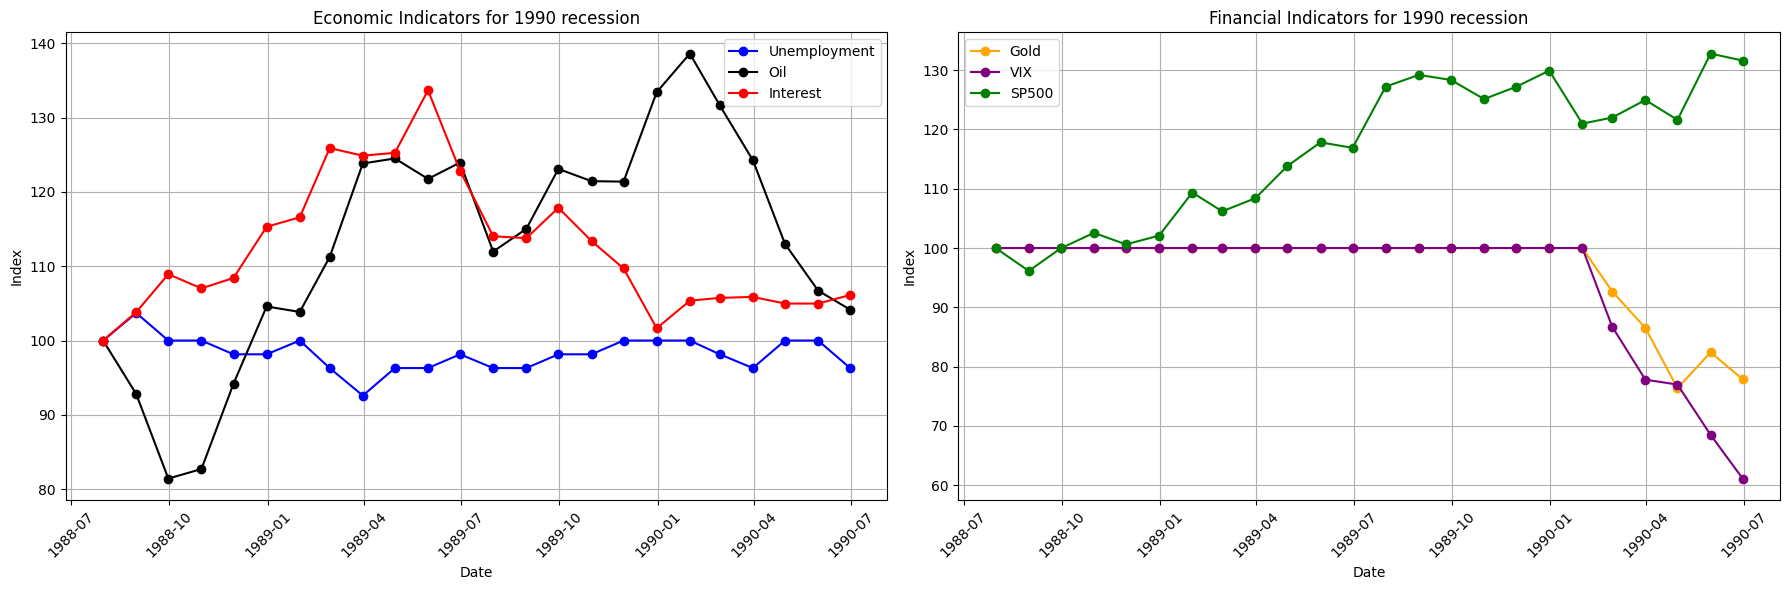

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Economic
for col in econ_cols:
    axes[0].plot(normalized_df_1990.index, normalized_df_1990[col],
                 marker="o", label=col, color=color_map[col])

axes[0].set_title("Economic Indicators for 1990 recession")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Index")
axes[0].legend()
axes[0].grid(True)
axes[0].tick_params(axis="x", rotation=45)

# Financial
for col in fin_cols:
    axes[1].plot(normalized_df_1990.index, normalized_df_1990[col],
                 marker="o", label=col, color=color_map[col])

axes[1].set_title("Financial Indicators for 1990 recession")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Index")
axes[1].legend()
axes[1].grid(True)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Compare with 2001 Dot Com Burst Recession


In [34]:
# Combine all monthly datasets
df_2001 = pd.concat([
    unemployment_monthly,
    interest_monthly,
    oil_monthly,
    sp500_monthly,
    vix_monthly,
    gold_monthly
], axis=1)

# Rename column names
df_2001 = df_2001.rename(columns={
    '^GSPC': 'SP500',
    '^VIX': 'VIX',
    '^XAU': 'Gold',
})

# Filter date range
df_2001 = df_2001.loc["1999-03-01":"2001-02-28"]

# Handle missing values (important)
df_2001 = df_2001.ffill().bfill()

df_2001

,Unemployment,Interest,Oil,SP500,VIX,Gold
1999-03-31,4.2,4.98,16.66,1286.369995,23.260000,59.759998
1999-04-30,4.3,5.03,18.69,1335.180054,25.070000,73.419998
1999-05-31,4.2,4.61,16.85,1301.839966,25.389999,60.869999
1999-06-30,4.3,5.12,19.33,1372.709961,21.090000,66.930000
1999-07-31,4.3,5.07,20.52,1328.719971,24.639999,62.869999
1999-08-31,4.2,5.57,22.15,1320.410034,24.450001,67.339996
1999-09-30,4.2,5.51,24.54,1282.709961,25.410000,80.260002
1999-10-31,4.1,5.27,21.79,1362.930054,22.200001,69.550003
1999-11-30,4.1,5.63,24.87,1388.910034,24.180000,67.040001
1999-12-31,4.0,3.99,25.76,1469.250000,24.639999,67.970001


## Heatmap for % changes in financial indicators

### Monthly Data

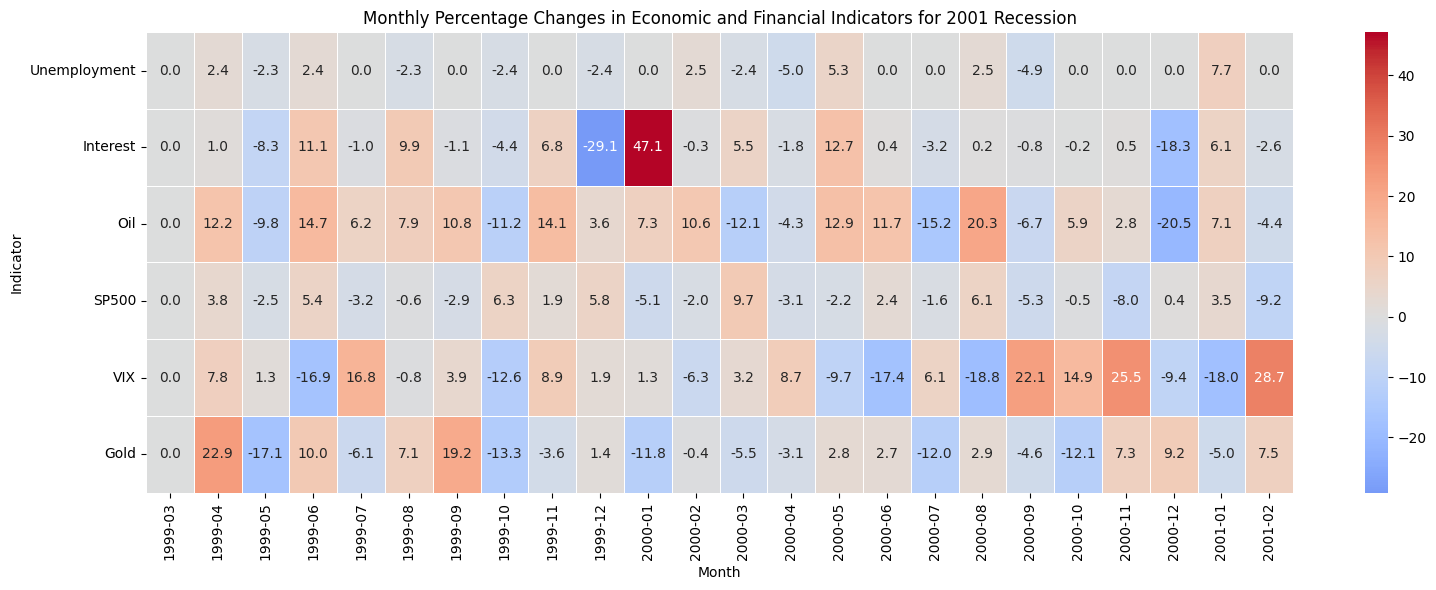

In [62]:
pct_change_df_2001 = df_2001.pct_change() * 100
pct_change_df_2001 = pct_change_df_2001.fillna(0)

# transpose so indicators are rows
heatmap_data_2001 = pct_change_df_2001.T

# cleaner month labels
heatmap_data_2001.columns = [d.strftime("%Y-%m") for d in heatmap_data_2001.columns]

plt.figure(figsize=(16, 6))
sns.heatmap(
    heatmap_data_2001,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Monthly Percentage Changes in Economic and Financial Indicators for 2001 Recession")
plt.xlabel("Month")
plt.ylabel("Indicator")
plt.tight_layout()
plt.show()


### Different time periods

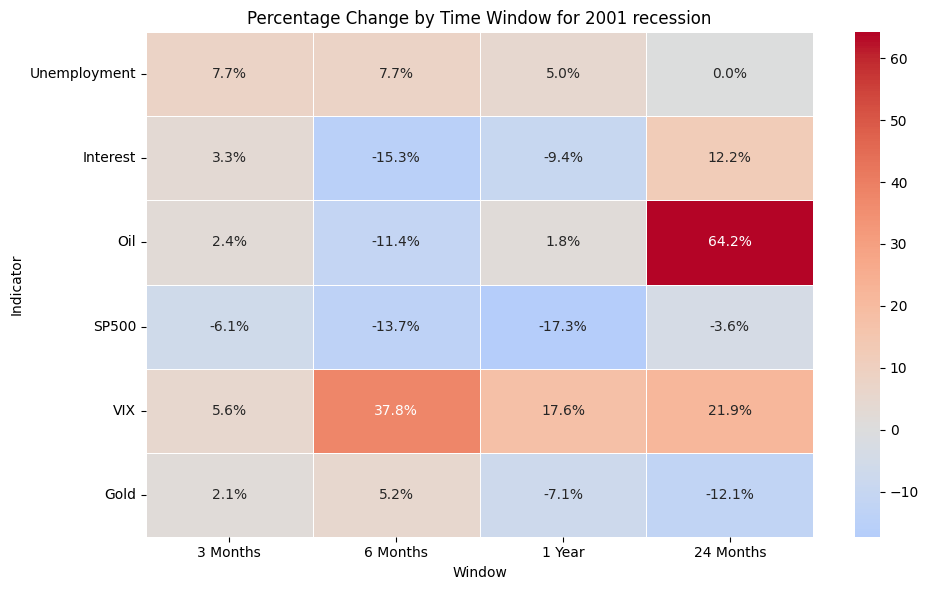

In [45]:
windows_2001 = {
    "3 Months": ("2000-12-01", "2001-02-28"),
    "6 Months": ("2000-09-01", "2001-02-28"),
    "1 Year":   ("2000-03-01", "2001-02-28"),
    "24 Months":("1999-03-01", "2001-02-28")
}

all_cols_2001 = df_2001.columns.tolist()

heatmap_values_2001 = {}

for label, (start_date, end_date) in windows_2001.items():
    window_df_2001 = df_2001.loc[start_date:end_date, all_cols_2001].copy()

    # If a column is all NaN in a window, return 0
    start_vals_2001 = window_df_2001.iloc[0]
    end_vals_2001 = window_df_2001.iloc[-1]

    pct_change_2001 = ((end_vals_2001 / start_vals_2001) - 1) * 100

    # clean up inf/nan
    pct_change_2001 = pct_change_2001.replace([np.inf, -np.inf], np.nan).fillna(0)

    heatmap_values_2001[label] = pct_change_2001

heatmap_df_2001 = pd.DataFrame(heatmap_values_2001)

annot_data_2001 = heatmap_df_2001.round(1).astype(str) + "%"

plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_df_2001,
    annot=annot_data_2001,
    fmt="",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Percentage Change by Time Window for 2001 recession")
plt.xlabel("Window")
plt.ylabel("Indicator")
plt.tight_layout()
plt.show()

## Side by Side line graphs
These line graphs will show the trend of each economic data.

In [47]:
normalized_df_2001 = df_2001[all_cols_2001].copy()

for col in all_cols_2001:
    first_valid = normalized_df_2001[col].dropna()
    if not first_valid.empty:
        base_value = first_valid.iloc[0]
        normalized_df_2001[col] = (normalized_df_2001[col] / base_value) * 100
    else:
        normalized_df_2001[col] = 100  # fallback if entire column missing

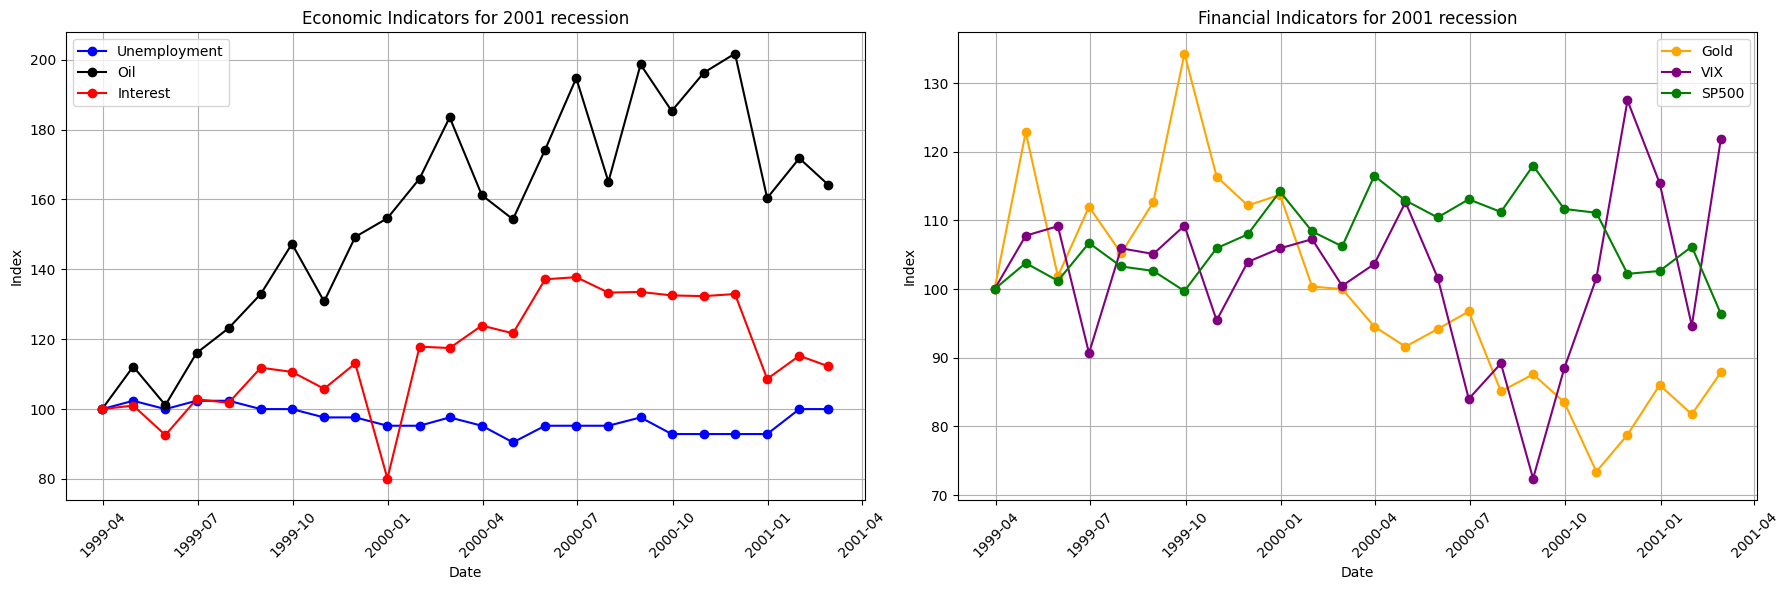

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Economic
for col in econ_cols:
    axes[0].plot(normalized_df_2001.index, normalized_df_2001[col],
                 marker="o", label=col, color=color_map[col])

axes[0].set_title("Economic Indicators for 2001 recession")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Index")
axes[0].legend()
axes[0].grid(True)
axes[0].tick_params(axis="x", rotation=45)

# Financial
for col in fin_cols:
    axes[1].plot(normalized_df_2001.index, normalized_df_2001[col],
                 marker="o", label=col, color=color_map[col])

axes[1].set_title("Financial Indicators for 2001 recession")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Index")
axes[1].legend()
axes[1].grid(True)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Compare with 2008 Housing Crisis Recession


In [50]:
# Combine all monthly datasets
df_2008 = pd.concat([
    unemployment_monthly,
    interest_monthly,
    oil_monthly,
    sp500_monthly,
    vix_monthly,
    gold_monthly
], axis=1)

# Rename column names
df_2008 = df_2008.rename(columns={
    '^GSPC': 'SP500',
    '^VIX': 'VIX',
    '^XAU': 'Gold',
})

# Filter date range
df_2008 = df_2008.loc["2006-01-01":"2007-12-31"]

# Handle missing values (important)
df_2008 = df_2008.ffill().bfill()

df_2008

,Unemployment,Interest,Oil,SP500,VIX,Gold
2006-01-31,4.7,4.47,67.86,1280.079956,12.950000,154.190002
2006-02-28,4.8,4.52,61.37,1280.660034,12.340000,133.350006
2006-03-31,4.7,5.00,66.25,1294.869995,11.390000,141.619995
2006-04-30,4.7,4.86,71.80,1310.609985,11.590000,158.110001
2006-05-31,4.6,5.05,71.42,1270.089966,16.440001,142.600006
2006-06-30,4.6,5.05,73.94,1270.199951,13.080000,143.570007
2006-07-31,4.7,5.31,74.56,1276.660034,14.950000,141.850006
2006-08-31,4.7,5.31,70.38,1303.819946,12.310000,146.720001
2006-09-30,4.5,5.34,62.90,1335.849976,11.980000,128.419998
2006-10-31,4.4,5.31,58.72,1377.939941,11.100000,137.309998


## Heatmap for % changes in financial indicators

### Monthly Data

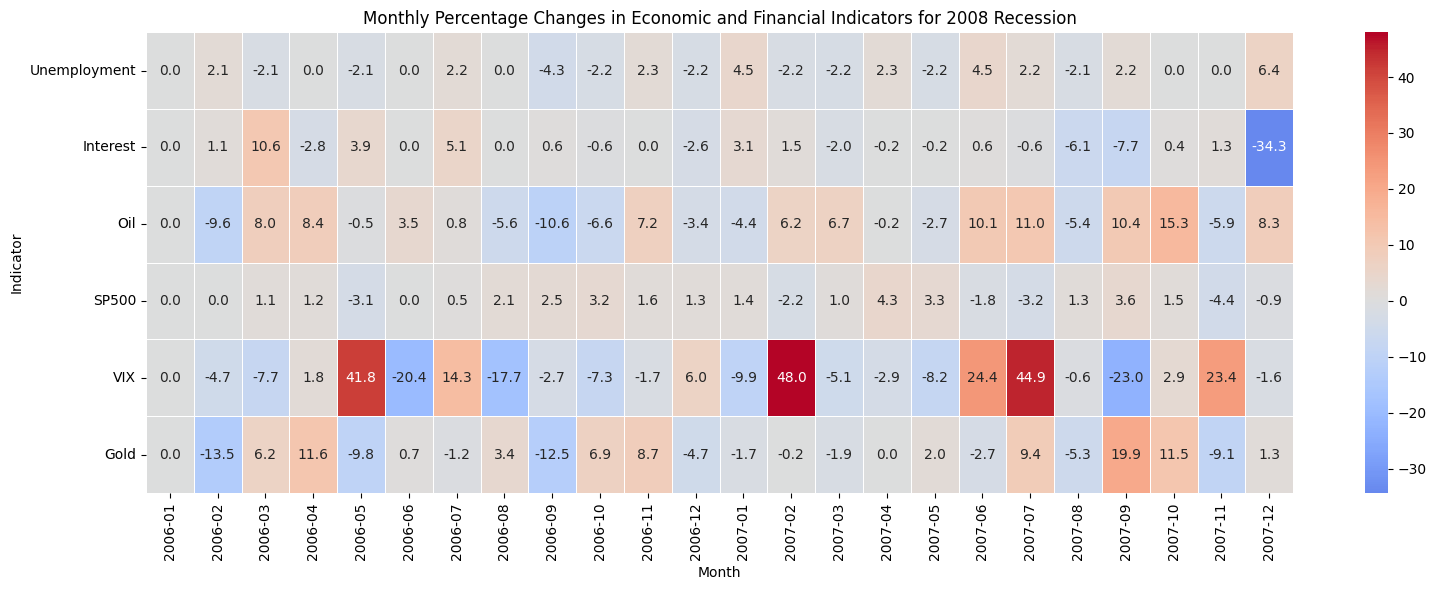

In [63]:
pct_change_df_2008 = df_2008.pct_change() * 100
pct_change_df_2008 = pct_change_df_2008.fillna(0)

# transpose so indicators are rows
heatmap_data_2008 = pct_change_df_2008.T

# cleaner month labels
heatmap_data_2008.columns = [d.strftime("%Y-%m") for d in heatmap_data_2008.columns]

plt.figure(figsize=(16, 6))
sns.heatmap(
    heatmap_data_2008,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Monthly Percentage Changes in Economic and Financial Indicators for 2008 Recession")
plt.xlabel("Month")
plt.ylabel("Indicator")
plt.tight_layout()
plt.show()


### Different time periods

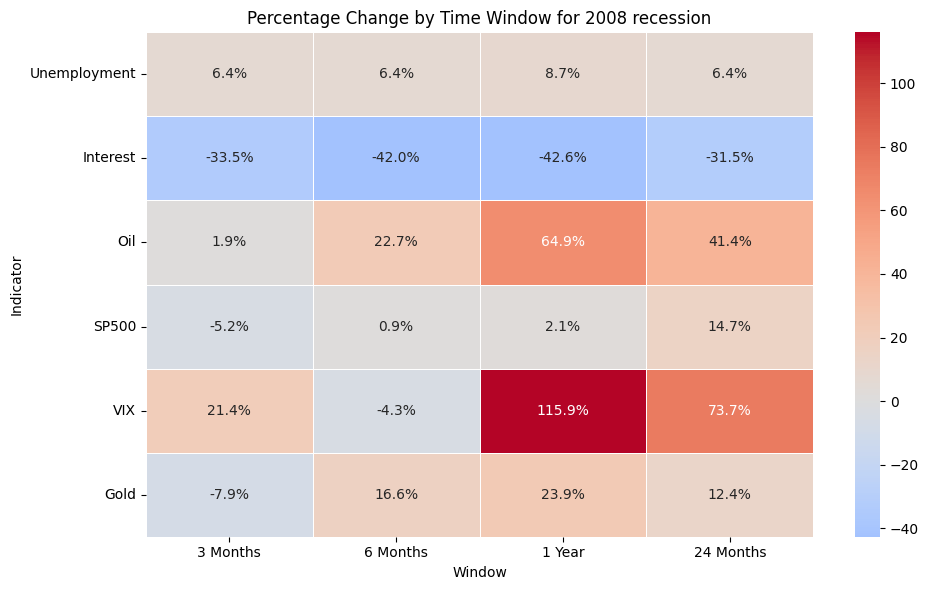

In [52]:
windows_2008 = {
    "3 Months": ("2007-10-01", "2007-12-31"),
    "6 Months": ("2007-07-01", "2007-12-31"),
    "1 Year":   ("2007-01-01", "2007-12-31"),
    "24 Months":("2006-01-01", "2007-12-31")
}

all_cols_2008 = df_2008.columns.tolist()

heatmap_values_2008 = {}

for label, (start_date, end_date) in windows_2008.items():
    window_df_2008 = df_2008.loc[start_date:end_date, all_cols_2008].copy()

    # If a column is all NaN in a window, return 0
    start_vals_2008 = window_df_2008.iloc[0]
    end_vals_2008 = window_df_2008.iloc[-1]

    pct_change_2008 = ((end_vals_2008 / start_vals_2008) - 1) * 100

    # clean up inf/nan
    pct_change_2008 = pct_change_2008.replace([np.inf, -np.inf], np.nan).fillna(0)

    heatmap_values_2008[label] = pct_change_2008

heatmap_df_2008 = pd.DataFrame(heatmap_values_2008)

annot_data_2008 = heatmap_df_2008.round(1).astype(str) + "%"

plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_df_2008,
    annot=annot_data_2008,
    fmt="",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Percentage Change by Time Window for 2008 recession")
plt.xlabel("Window")
plt.ylabel("Indicator")
plt.tight_layout()
plt.show()

## Side by Side line graphs
These line graphs will show the trend of each economic data.

In [53]:
normalized_df_2008 = df_2008[all_cols_2008].copy()

for col in all_cols_2008:
    first_valid = normalized_df_2008[col].dropna()
    if not first_valid.empty:
        base_value = first_valid.iloc[0]
        normalized_df_2008[col] = (normalized_df_2008[col] / base_value) * 100
    else:
        normalized_df_2008[col] = 100  # fallback if entire column missing

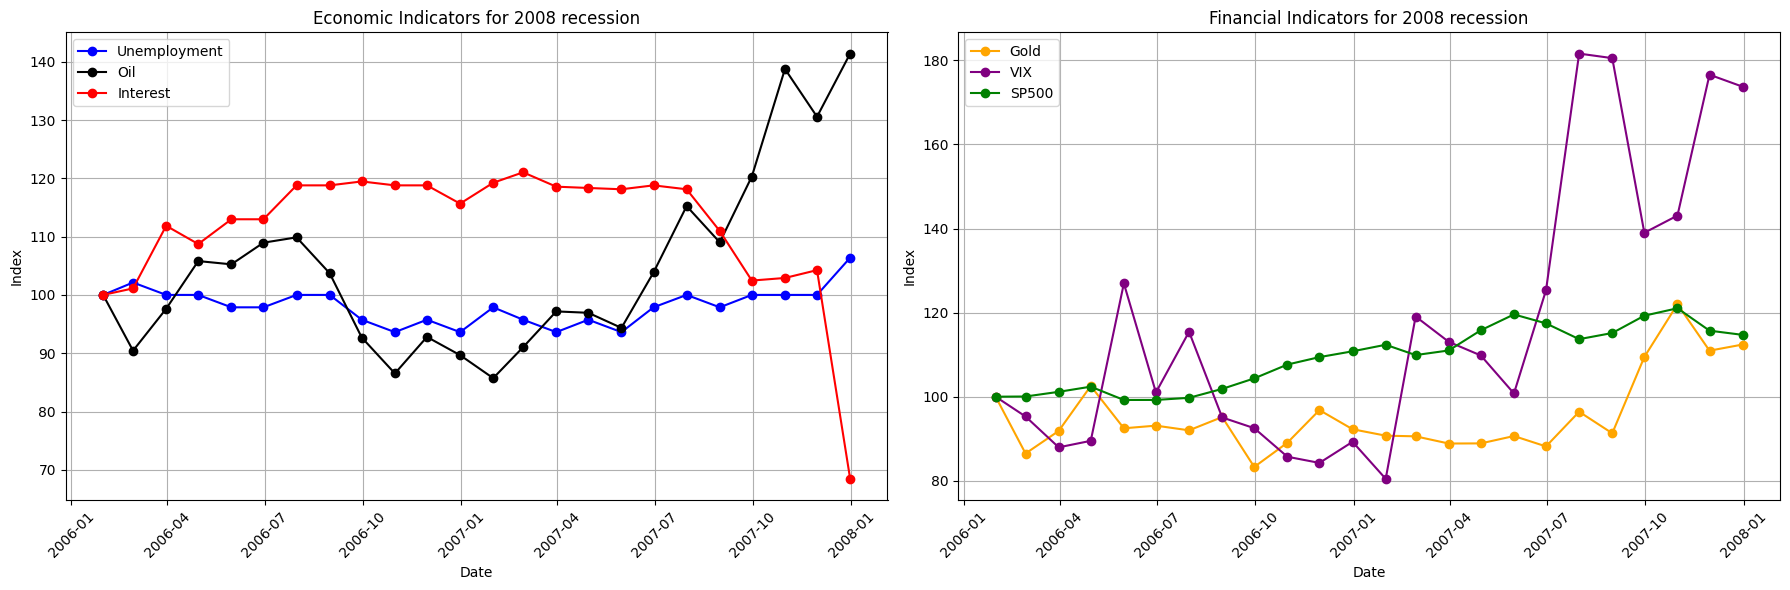

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Economic
for col in econ_cols:
    axes[0].plot(normalized_df_2008.index, normalized_df_2008[col],
                 marker="o", label=col, color=color_map[col])

axes[0].set_title("Economic Indicators for 2008 recession")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Index")
axes[0].legend()
axes[0].grid(True)
axes[0].tick_params(axis="x", rotation=45)

# Financial
for col in fin_cols:
    axes[1].plot(normalized_df_2008.index, normalized_df_2008[col],
                 marker="o", label=col, color=color_map[col])

axes[1].set_title("Financial Indicators for 2008 recession")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Index")
axes[1].legend()
axes[1].grid(True)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Compare with 2020 Pandemic Recession


In [55]:
# Combine all monthly datasets
df_2020 = pd.concat([
    unemployment_monthly,
    interest_monthly,
    oil_monthly,
    sp500_monthly,
    vix_monthly,
    gold_monthly
], axis=1)

# Rename column names
df_2020 = df_2020.rename(columns={
    '^GSPC': 'SP500',
    '^VIX': 'VIX',
    '^XAU': 'Gold',
})

# Filter date range
df_2020 = df_2020.loc["2018-01-01":"2019-12-31"]

# Handle missing values (important)
df_2020 = df_2020.ffill().bfill()

df_2020

,Unemployment,Interest,Oil,SP500,VIX,Gold
2018-01-31,4.0,1.34,64.82,2823.810059,13.540000,87.660004
2018-02-28,4.1,1.35,61.43,2713.830078,19.850000,78.269997
2018-03-31,4.0,1.67,64.87,2640.870117,19.969999,81.120003
2018-04-30,4.0,1.69,68.56,2648.050049,15.930000,81.150002
2018-05-31,3.8,1.70,66.98,2705.270020,15.430000,83.320000
2018-06-30,4.0,1.91,74.13,2718.370117,16.090000,81.589996
2018-07-31,3.8,1.91,69.88,2816.290039,12.830000,77.300003
2018-08-31,3.8,1.91,69.84,2901.520020,12.860000,66.239998
2018-09-30,3.7,2.18,73.16,2913.979980,12.120000,65.180000
2018-10-31,3.8,2.20,65.31,2711.739990,21.230000,64.279999


## Heatmap for % changes in financial indicators

### Monthly Data

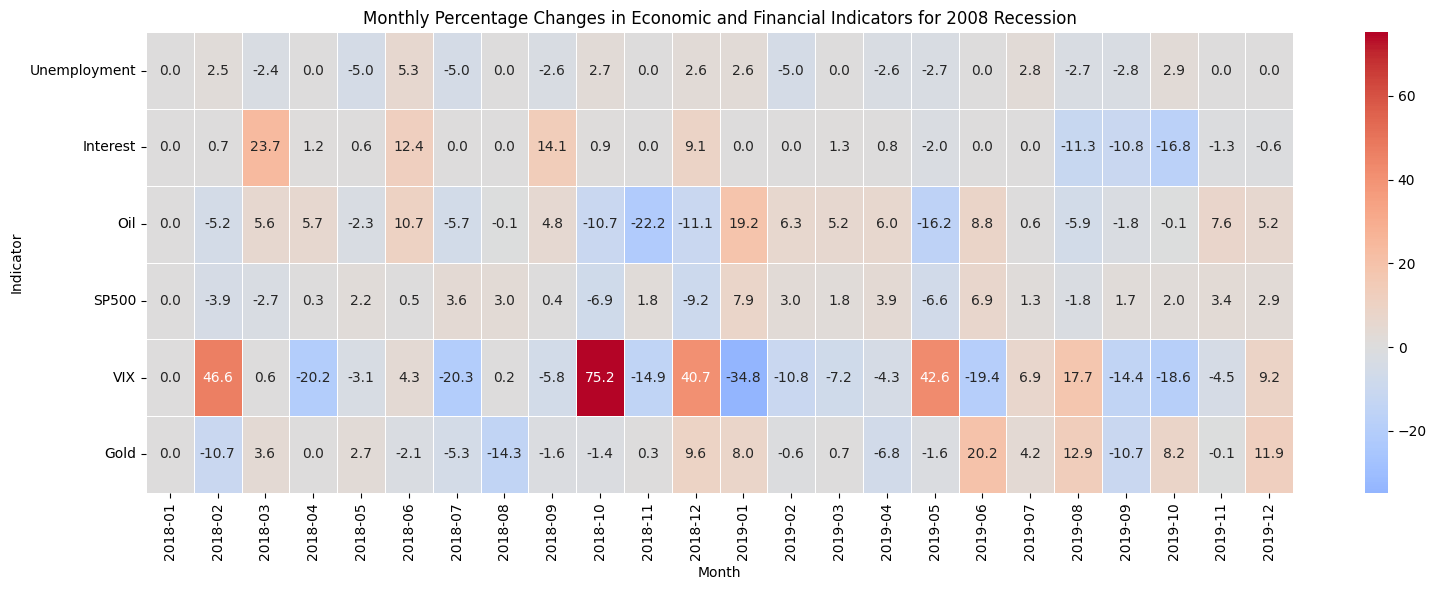

In [57]:
pct_change_df_2020 = df_2020.pct_change() * 100
pct_change_df_2020 = pct_change_df_2020.fillna(0)

# transpose so indicators are rows
heatmap_data_2020 = pct_change_df_2020.T

# cleaner month labels
heatmap_data_2020.columns = [d.strftime("%Y-%m") for d in heatmap_data_2020.columns]

plt.figure(figsize=(16, 6))
sns.heatmap(
    heatmap_data_2020,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Monthly Percentage Changes in Economic and Financial Indicators for 2008 Recession")
plt.xlabel("Month")
plt.ylabel("Indicator")
plt.tight_layout()
plt.show()


### Different time periods

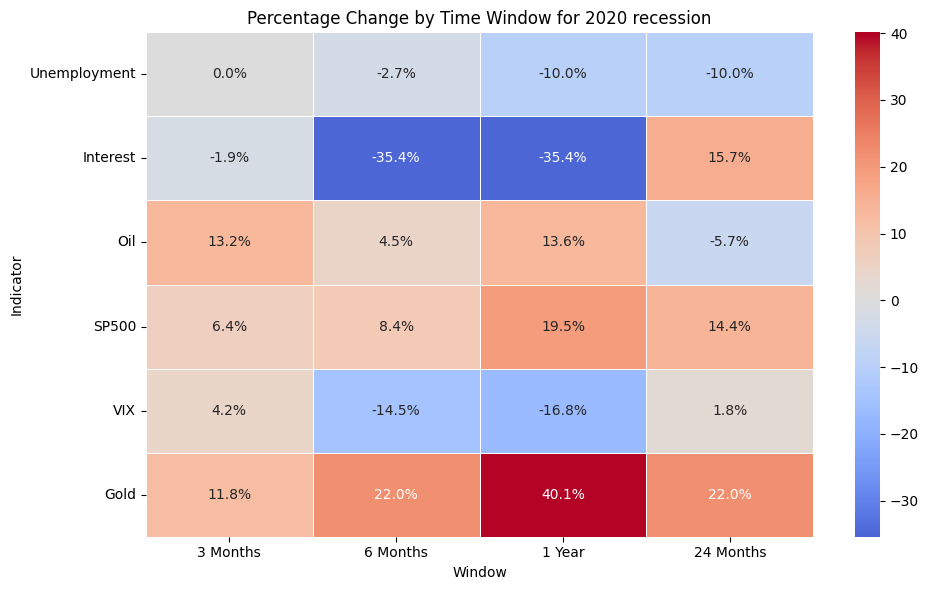

In [58]:
windows_2020 = {
    "3 Months": ("2019-10-01", "2019-12-31"),
    "6 Months": ("2019-07-01", "2019-12-31"),
    "1 Year":   ("2019-01-01", "2019-12-31"),
    "24 Months":("2018-01-01", "2019-12-31")
}

all_cols_2020 = df_2020.columns.tolist()

heatmap_values_2020 = {}

for label, (start_date, end_date) in windows_2020.items():
    window_df_2020 = df_2020.loc[start_date:end_date, all_cols_2020].copy()

    # If a column is all NaN in a window, return 0
    start_vals_2020 = window_df_2020.iloc[0]
    end_vals_2020 = window_df_2020.iloc[-1]

    pct_change_2020 = ((end_vals_2020 / start_vals_2020) - 1) * 100

    # clean up inf/nan
    pct_change_2020 = pct_change_2020.replace([np.inf, -np.inf], np.nan).fillna(0)

    heatmap_values_2020[label] = pct_change_2020

heatmap_df_2020 = pd.DataFrame(heatmap_values_2020)

annot_data_2020 = heatmap_df_2020.round(1).astype(str) + "%"

plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_df_2020,
    annot=annot_data_2020,
    fmt="",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Percentage Change by Time Window for 2020 recession")
plt.xlabel("Window")
plt.ylabel("Indicator")
plt.tight_layout()
plt.show()

## Side by Side line graphs
These line graphs will show the trend of each economic data.

In [59]:
normalized_df_2020 = df_2020[all_cols_2020].copy()

for col in all_cols_2020:
    first_valid = normalized_df_2020[col].dropna()
    if not first_valid.empty:
        base_value = first_valid.iloc[0]
        normalized_df_2020[col] = (normalized_df_2020[col] / base_value) * 100
    else:
        normalized_df_2020[col] = 100  # fallback if entire column missing

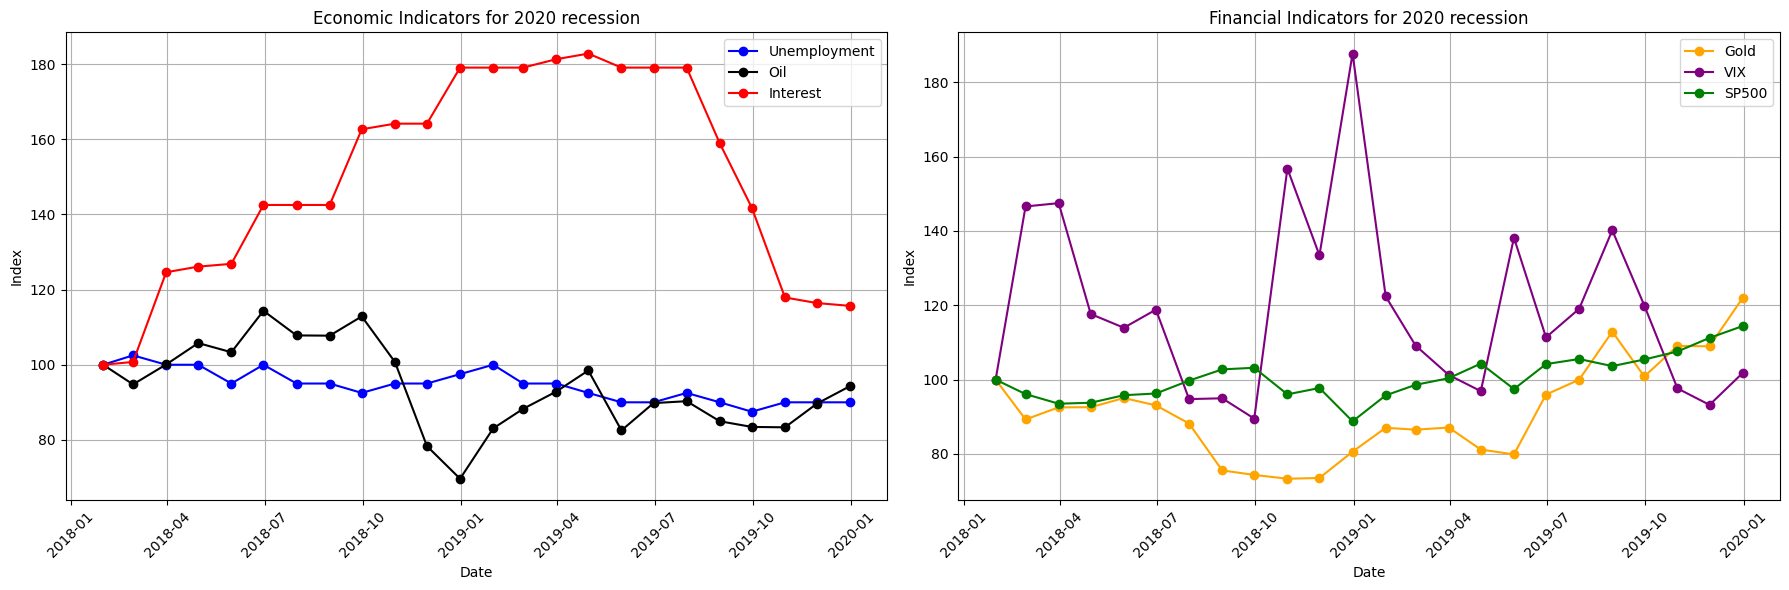

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Economic
for col in econ_cols:
    axes[0].plot(normalized_df_2020.index, normalized_df_2020[col],
                 marker="o", label=col, color=color_map[col])

axes[0].set_title("Economic Indicators for 2020 recession")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Index")
axes[0].legend()
axes[0].grid(True)
axes[0].tick_params(axis="x", rotation=45)

# Financial
for col in fin_cols:
    axes[1].plot(normalized_df_2020.index, normalized_df_2020[col],
                 marker="o", label=col, color=color_map[col])

axes[1].set_title("Financial Indicators for 2020 recession")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Index")
axes[1].legend()
axes[1].grid(True)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()